In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
import numpy as np

In [56]:
dataset = pd.read_csv("../datasets/regularization_house_dataset.csv")
dataset.columns = dataset.columns.str.strip()
dataset.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,4,4.0,2068,6348,1.0,1,0,5,1015,1387,1914,1972,1258712
1,5,2.2,1456,7190,1.5,1,4,4,2500,1405,1920,2008,1037414
2,3,3.4,3238,2256,2.5,0,3,1,2944,531,1918,1994,1442146
3,5,3.4,3998,4376,1.0,1,2,4,538,955,1959,1967,1873390
4,5,1.5,2136,6645,1.0,0,1,1,1386,151,1992,2016,1046157


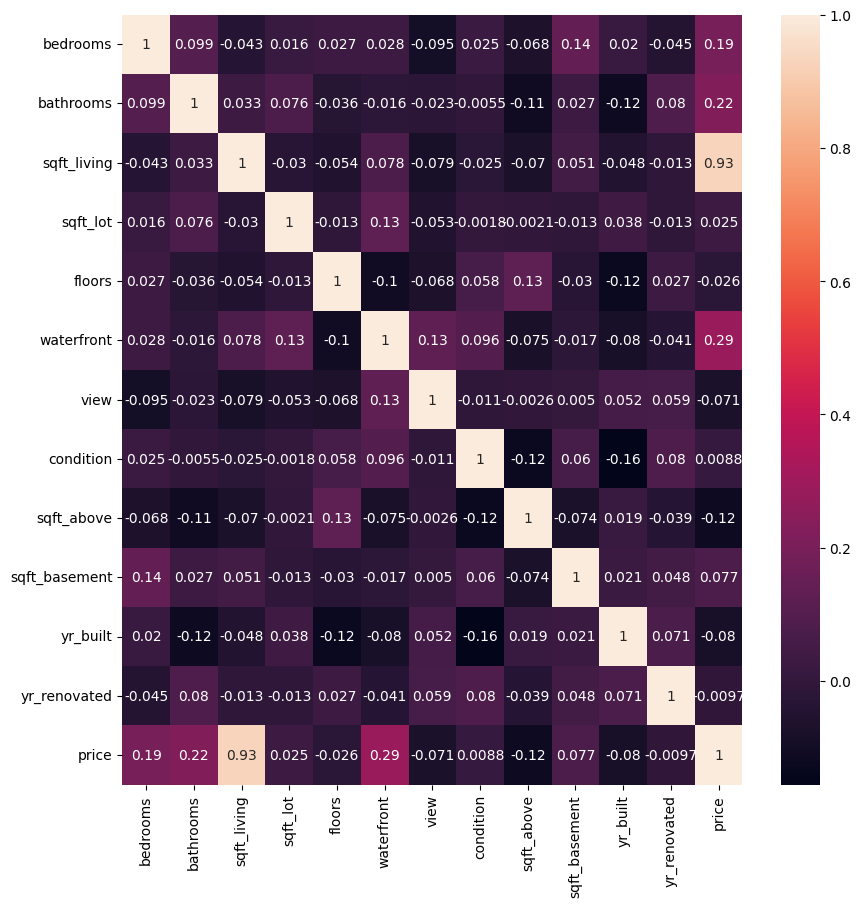

In [57]:
plt.figure(figsize=[10,10])
sns.heatmap(data=dataset.corr(),annot=True)
plt.show()

In [58]:
x= dataset.iloc[:,:-1]
y = dataset["price"]

In [59]:
sc   =StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x),columns=x.columns)

In [60]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

LinearRegression

In [61]:
lr = LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_test,y_test)*100


99.02395624894326

In [64]:
print(mean_squared_error(y_test,lr.predict(x_test)))
print(mean_absolute_error(y_test,lr.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,lr.predict(x_test))))

941940590.1999874
25915.896422990794
30691.050653243976


In [49]:
lr.coef_

array([ 71229.41898557,  58356.418088  , 312575.4145441 ,   3075.82728722,
        15962.11166242,  72124.55143397,   1586.95678874,   2473.73789321,
        -4622.28153439,   -712.75508614,   1159.52188563,   1229.51908109])

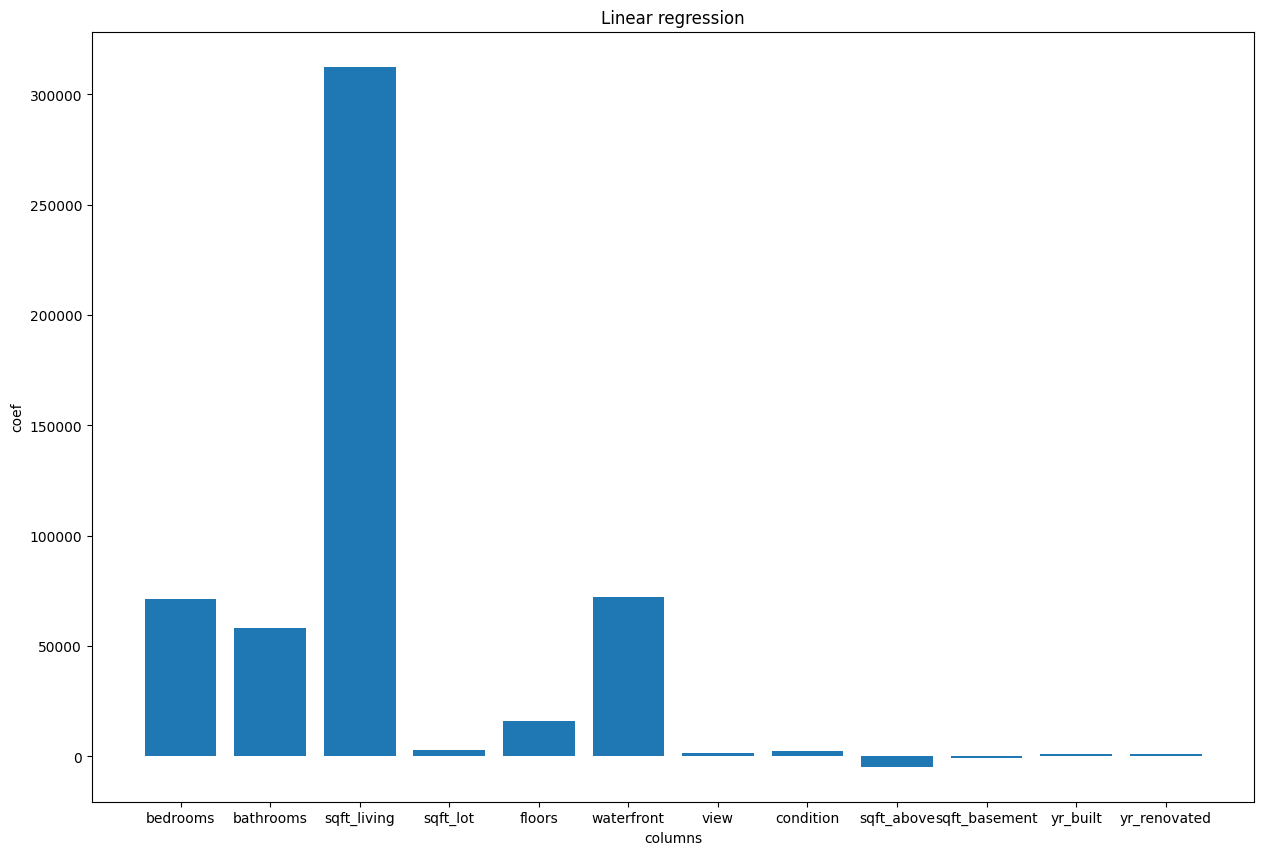

In [50]:
plt.figure(figsize=[15,10])
plt.bar(x.columns,lr.coef_)
plt.title("Linear regression")
plt.xlabel("columns")
plt.ylabel("coef")
plt.show()

lasso

In [51]:
la = Lasso(alpha=0.5)
la.fit(x_train,y_train)
la.score(x_test,y_test)*100

99.02397289058331

In [68]:
print(mean_squared_error(y_test,la.predict(x_test)))
print(mean_absolute_error(y_test,la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,la.predict(x_test))))

941924530.0221266
25915.7588152152
30690.789009442662


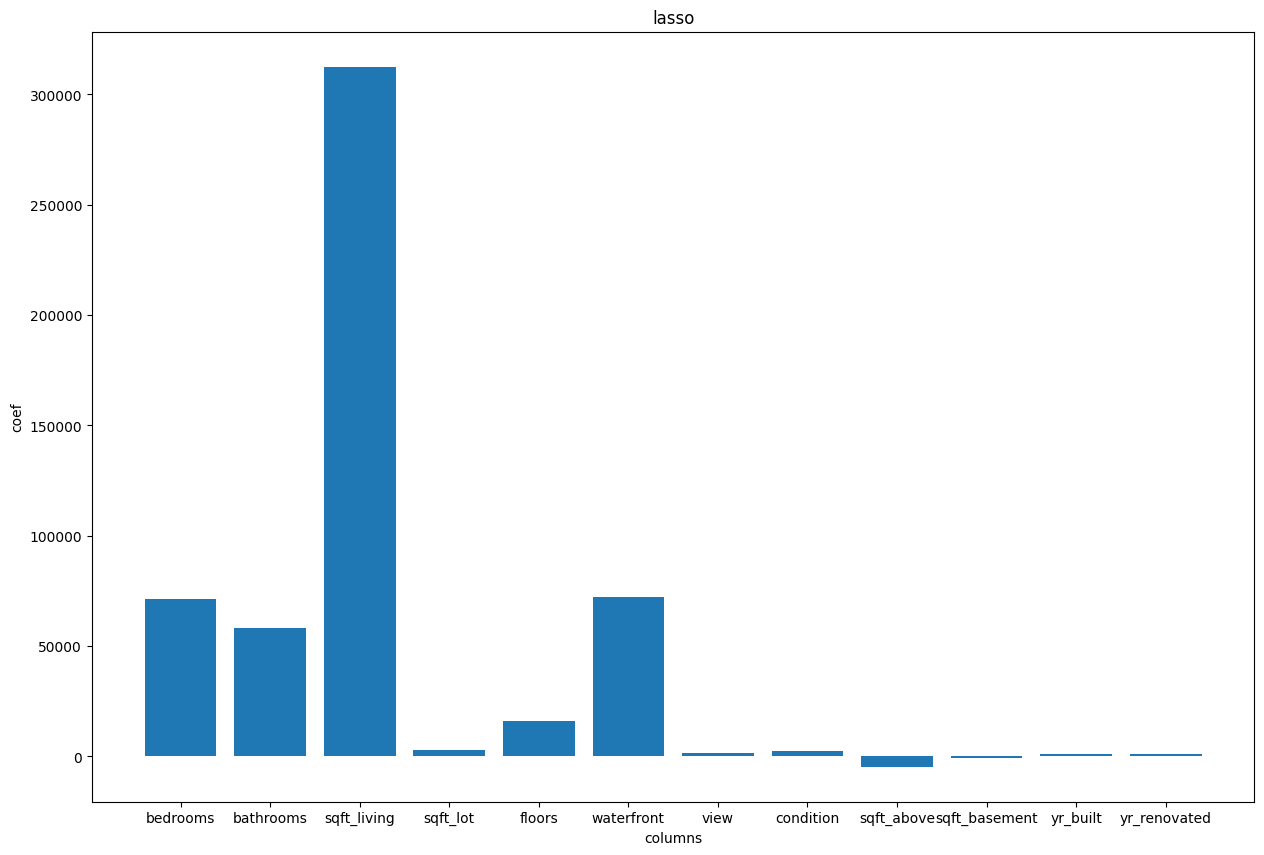

In [52]:
plt.figure(figsize=[15,10])
plt.bar(x.columns,la.coef_)
plt.title("lasso")
plt.xlabel("columns")
plt.ylabel("coef")
plt.show()

ridge


In [53]:
ri = Ridge(alpha=10)
ri.fit(x_train,y_train)
ri.score(x_test,y_test)*100

98.56224900995518

In [69]:
print(mean_squared_error(y_test,ri.predict(x_test)))
print(mean_absolute_error(y_test,ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,ri.predict(x_test))))

1387515687.3420835
32758.162457018614
37249.371636875745


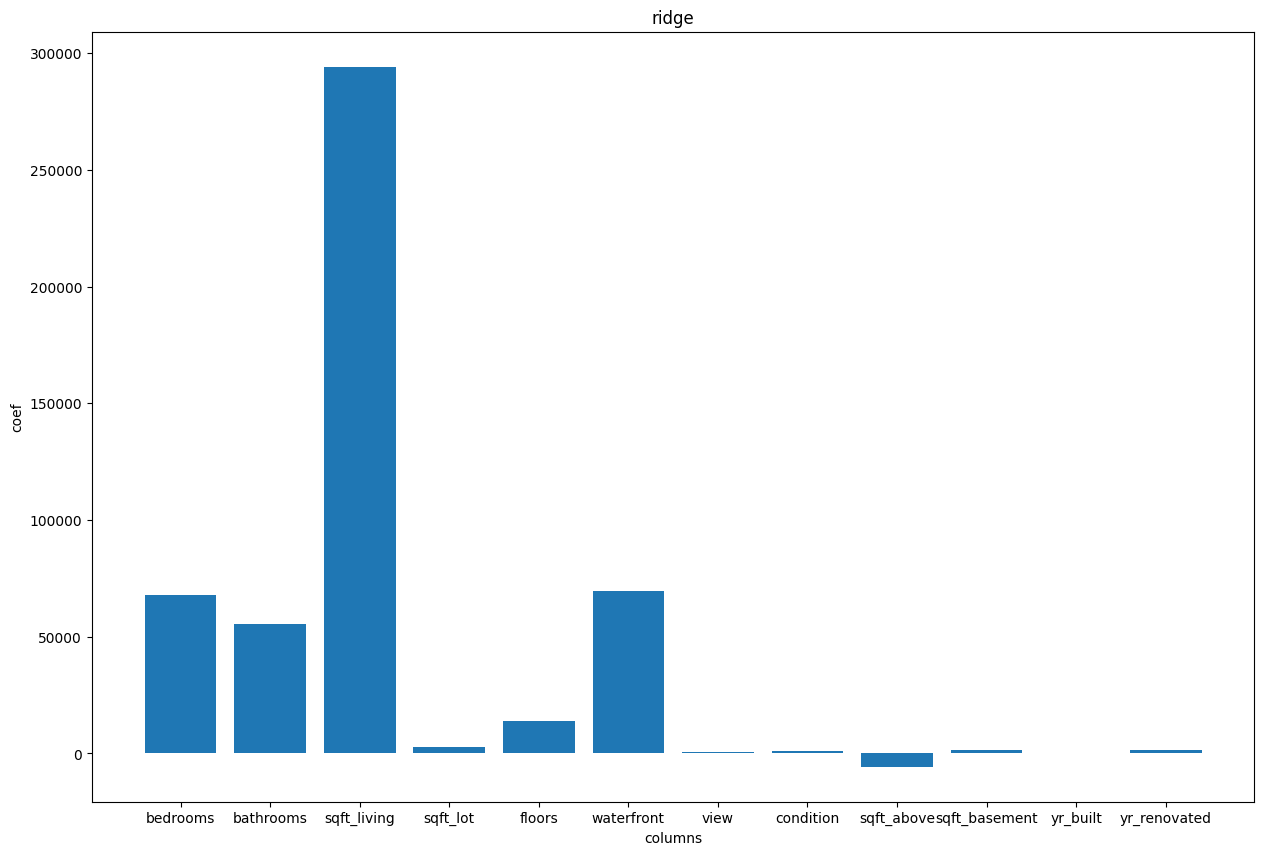

In [54]:
plt.figure(figsize=[15,10])
plt.bar(x.columns,ri.coef_)
plt.title("ridge")
plt.xlabel("columns")
plt.ylabel("coef")
plt.show()

In [72]:
df = pd.DataFrame({
    "col_name": x.columns,
    "LinearRegression": lr.coef_,
    "Lasso": la.coef_,
    "Ridge": ri.coef_
})


In [73]:
df

,col_name,LinearRegression,Lasso,Ridge
0,bedrooms,71229.418986,71229.047693,67697.989444
1,bathrooms,58356.418088,58355.853336,55583.691269
2,sqft_living,312575.414544,312574.761634,294241.431574
3,sqft_lot,3075.827287,3075.413100,2504.622812
4,floors,15962.111662,15961.475083,13865.257114
5,waterfront,72124.551434,72124.244529,69467.619206
6,view,1586.956789,1586.346630,699.275197
7,condition,2473.737893,2473.050517,1184.311561
8,sqft_above,-4622.281534,-4621.839779,-5705.144815
9,sqft_basement,-712.755086,-712.080378,1509.266277
